# 05 - ML Temperature Prediction

Phase 1 benchmark for the residential thermal digital twin.

Goal: predict indoor temperature 1 hour ahead for:
- `temp_salon_c`
- `temp_kids_c`

Using:
- indoor temperature/humidity
- outdoor north/south temperatures/humidity
- thermal lag features
- time-cycle features
- solar proxy: `temp_out_2_n_c - temp_out_1_b_c`

This notebook uses the hourly dataset exported from the Home Assistant.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.multioutput import MultiOutputRegressor


## 1. Load hourly dataset

In [2]:
DATA_PATH = Path("../data/processed/TempHumData_27_4_26.csv")

# If running this notebook from a different location, update DATA_PATH accordingly.
df = pd.read_csv(DATA_PATH)

df["time"] = pd.to_datetime(df["time"])
df = df.set_index("time").sort_index()

cutoff = "2026-02-22 17:00:00"
df = df[df.index >= cutoff]

print(df.shape)
display(df.head())
display(df.tail())

(1524, 8)


,temp_salon_c,temp_kids_c,hum_salon,hum_kids,temp_out_1_b_c,hum_out_1_b,temp_out_2_n_c,hum_out_2_n
time,,,,,,,,
2026-02-22 17:00:00,18.45,19.84,63.91,55.66,9.89,66.82,17.01,55.45
2026-02-22 18:00:00,19.33,20.04,63.81,56.66,9.23,70.83,11.63,63.32
2026-02-22 19:00:00,19.07,19.65,65.78,60.08,8.89,70.79,10.33,66.01
2026-02-22 20:00:00,19.44,19.84,66.32,61.13,8.64,71.44,9.66,68.00
2026-02-22 21:00:00,19.26,19.54,65.34,61.40,8.44,75.14,9.39,71.99


,temp_salon_c,temp_kids_c,hum_salon,hum_kids,temp_out_1_b_c,hum_out_1_b,temp_out_2_n_c,hum_out_2_n
time,,,,,,,,
2026-04-27 01:00:00,20.5,20.5,48.06,45.62,18.49,34.92,17.34,36.65
2026-04-27 02:00:00,20.5,20.5,47.60,46.10,17.97,36.76,16.76,38.86
2026-04-27 03:00:00,20.5,20.5,47.60,46.10,17.49,39.41,16.29,41.62
2026-04-27 04:00:00,20.5,20.5,47.60,47.02,17.03,42.39,15.92,44.46
2026-04-27 05:00:00,20.5,20.5,47.60,47.10,16.72,44.56,15.65,46.76


## 2. Quick data quality check

In [3]:
print("Date range:", df.index.min(), "→", df.index.max())
print("\nMissing values:")
display(df.isna().sum())

# Verify hourly spacing
time_diffs = df.index.to_series().diff().dropna()
display(time_diffs.value_counts().head())


Date range: 2026-02-22 17:00:00 → 2026-04-27 05:00:00

Missing values:


temp_salon_c      0
temp_kids_c       4
hum_salon         0
hum_kids          4
temp_out_1_b_c    0
hum_out_1_b       0
temp_out_2_n_c    0
hum_out_2_n       0
dtype: int64

0 days 01:00:00    1522
0 days 02:00:00       1
Name: time, dtype: int64

## 3. Clean and interpolate small gaps

In [4]:
# Hourly grid, in case any timestamps are missing
df = df.resample("1h").mean()

# Interpolate short gaps only. Long initial gaps in outdoor sensors remain NaN and will be dropped later.
df = df.interpolate(methods="time", limit=4)

# Optional: add mean outdoor conditions if both sides exist
df["temp_out_mean_c"] = df[["temp_out_1_b_c", "temp_out_2_n_c"]].mean(axis=1)
df["hum_out_mean"] = df[["hum_out_1_b", "hum_out_2_n"]].mean(axis=1)

# Solar / orientation proxy: south-facing outdoor sensor minus north-facing outdoor sensor.
# Confirm which outdoor sensor is north/south in your setup before interpreting physically.
df["solar_proxy_temp_delta"] = df["temp_out_2_n_c"] - df["temp_out_1_b_c"]

display(df.tail())

,temp_salon_c,temp_kids_c,hum_salon,hum_kids,temp_out_1_b_c,hum_out_1_b,temp_out_2_n_c,hum_out_2_n,temp_out_mean_c,hum_out_mean,solar_proxy_temp_delta
time,,,,,,,,,,,
2026-04-27 01:00:00,20.5,20.5,48.06,45.62,18.49,34.92,17.34,36.65,17.915,35.785,-1.15
2026-04-27 02:00:00,20.5,20.5,47.60,46.10,17.97,36.76,16.76,38.86,17.365,37.810,-1.21
2026-04-27 03:00:00,20.5,20.5,47.60,46.10,17.49,39.41,16.29,41.62,16.890,40.515,-1.20
2026-04-27 04:00:00,20.5,20.5,47.60,47.02,17.03,42.39,15.92,44.46,16.475,43.425,-1.11
2026-04-27 05:00:00,20.5,20.5,47.60,47.10,16.72,44.56,15.65,46.76,16.185,45.660,-1.07


## 4. Feature Engineering

In [25]:
def add_time_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()

    hour = out.index.hour
    dayofyear = out.index.dayofyear

    out["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24)

    out["doy_sin"] = np.sin(2 * np.pi * dayofyear / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * dayofyear / 365.25)

    out["is_weekend"] = (out.index.dayofweek >= 5).astype(int)
    return out


def add_lag_features(data, columns, lags):
    out = data.copy()
    for col in columns:
        for lag in lags:
            out[f"{col}_lag_{lag}h"] = out[col].shift(lag)
    return out


def add_rolling_features(data: pd.DataFrame, columns, windows) -> pd.DataFrame:
    out = data.copy()
    for col in columns:
        for window in windows:
            out[f"{col}_roll_mean_{window}h"] = out[col].rolling(window).mean()
            out[f"{col}_roll_std_{window}h"] = out[col].rolling(window).std()
    return out

In [34]:
feat = df.copy()
horizon = 1

feat["temp_diff_south"] = feat["temp_out_2_n_c"] - feat["temp_salon_c"]
feat["temp_diff_north"] = feat["temp_out_1_b_c"] - feat["temp_salon_c"]

feat["temp_salon_c_target_plus_1h"] = feat["temp_salon_c"].shift(-horizon)
feat["temp_kids_c_target_plus_1h"] = feat["temp_kids_c"].shift(-horizon)

# 3. Define target_cols AFTER have been created
target_cols = [
    "temp_salon_c_target_plus_1h",
    "temp_kids_c_target_plus_1h",
]

# 4. Sanity check: should return True
print("Targets exist in df_feat:")
for col in target_cols:
    print(col, col in feat.columns)

Targets exist in df_feat:
temp_salon_c_target_plus_1h True
temp_kids_c_target_plus_1h True


In [35]:
targets = ["temp_salon_c", "temp_kids_c"]
# base_series_for_lags = [
#     "temp_salon_c",
#     "temp_kids_c",
#     "temp_out_1_b_c",
#     "temp_out_2_n_c",
#     "temp_out_mean_c",
#     "solar_proxy_temp_delta",
# ]

horizon_hours = 1

feat = add_time_features(feat)
lag_cols = [
    "temp_salon_c",
    "temp_kids_c",
    "temp_out_1_b_c",
    "temp_out_2_n_c",
    "temp_out_mean_c",
    "solar_proxy_temp_delta",
]

feat = add_lag_features(feat, columns=lag_cols, lags=[1, 2, 3, 6, 12, 24, 48])

feat = add_rolling_features(
    feat,
    columns=["temp_salon_c", "temp_kids_c"],
    windows=[2, 3, 6, 12, 24, 48]
)

# for target in targets:
#     feat[f"target_{target}_plus_{horizon_hours}h"] = feat[target].shift(-horizon_hours)

feat = feat.dropna()

print(feat.shape)
display(feat.head())

# 7. Sanity check again
print("Columns with target:")
print([c for c in feat.columns if "target" in c])


(1476, 86)


,temp_salon_c,temp_kids_c,hum_salon,hum_kids,temp_out_1_b_c,hum_out_1_b,temp_out_2_n_c,hum_out_2_n,temp_out_mean_c,hum_out_mean,...,temp_kids_c_roll_mean_3h,temp_kids_c_roll_std_3h,temp_kids_c_roll_mean_6h,temp_kids_c_roll_std_6h,temp_kids_c_roll_mean_12h,temp_kids_c_roll_std_12h,temp_kids_c_roll_mean_24h,temp_kids_c_roll_std_24h,temp_kids_c_roll_mean_48h,temp_kids_c_roll_std_48h
time,,,,,,,,,,,,,,,,,,,,,
2026-02-24 17:00:00,17.30,19.10,64.40,56.07,15.75,53.24,19.64,41.33,17.695,47.285,...,19.110000,0.305123,18.803333,0.580781,18.245833,0.731840,18.560833,0.712887,18.691250,0.749030
2026-02-24 18:00:00,17.31,18.55,64.92,57.61,14.83,55.83,16.20,49.31,15.515,52.570,...,19.023333,0.440038,18.918333,0.395344,18.283333,0.735210,18.492917,0.624030,18.660208,0.722344
2026-02-24 19:00:00,18.29,19.28,68.54,58.50,14.24,59.77,15.01,55.48,14.625,57.625,...,18.976667,0.380307,19.063333,0.324879,18.386667,0.783458,18.485417,0.612883,18.652500,0.713477
2026-02-24 20:00:00,18.83,19.78,68.50,58.88,13.76,62.90,14.31,59.72,14.035,61.310,...,19.203333,0.618574,19.156667,0.439211,18.588333,0.806292,18.508333,0.651030,18.651250,0.711401
2026-02-24 21:00:00,18.56,19.64,69.60,61.37,13.36,63.33,13.74,60.62,13.550,61.975,...,19.566667,0.257941,19.295000,0.438896,18.766667,0.779922,18.530833,0.681009,18.653333,0.714200


Columns with target:
['temp_salon_c_target_plus_1h', 'temp_kids_c_target_plus_1h']


In [36]:
print(feat.columns)

Index(['temp_salon_c', 'temp_kids_c', 'hum_salon', 'hum_kids',
       'temp_out_1_b_c', 'hum_out_1_b', 'temp_out_2_n_c', 'hum_out_2_n',
       'temp_out_mean_c', 'hum_out_mean', 'solar_proxy_temp_delta',
       'temp_diff_south', 'temp_diff_north', 'temp_salon_c_target_plus_1h',
       'temp_kids_c_target_plus_1h', 'hour_sin', 'hour_cos', 'doy_sin',
       'doy_cos', 'is_weekend', 'temp_salon_c_lag_1h', 'temp_salon_c_lag_2h',
       'temp_salon_c_lag_3h', 'temp_salon_c_lag_6h', 'temp_salon_c_lag_12h',
       'temp_salon_c_lag_24h', 'temp_salon_c_lag_48h', 'temp_kids_c_lag_1h',
       'temp_kids_c_lag_2h', 'temp_kids_c_lag_3h', 'temp_kids_c_lag_6h',
       'temp_kids_c_lag_12h', 'temp_kids_c_lag_24h', 'temp_kids_c_lag_48h',
       'temp_out_1_b_c_lag_1h', 'temp_out_1_b_c_lag_2h',
       'temp_out_1_b_c_lag_3h', 'temp_out_1_b_c_lag_6h',
       'temp_out_1_b_c_lag_12h', 'temp_out_1_b_c_lag_24h',
       'temp_out_1_b_c_lag_48h', 'temp_out_2_n_c_lag_1h',
       'temp_out_2_n_c_lag_2h', 'tem

## 5. Train/test split — chronological, not random

In [37]:
# 8. X = all except targets
X = feat.drop(columns=target_cols)

# 9. y = Only targets
y = feat[target_cols]

print("X columns sample:")
print(X.columns[:10].tolist())

print("y columns:")
print(y.columns.tolist())

split_idx = int(len(feat) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train:", X_train.index.min(), "→", X_train.index.max(), X_train.shape)
print("Test:", X_test.index.min(), "→", X_test.index.max(), X_test.shape)


X columns sample:
['temp_salon_c', 'temp_kids_c', 'hum_salon', 'hum_kids', 'temp_out_1_b_c', 'hum_out_1_b', 'temp_out_2_n_c', 'hum_out_2_n', 'temp_out_mean_c', 'hum_out_mean']
y columns:
['temp_salon_c_target_plus_1h', 'temp_kids_c_target_plus_1h']
Train: 2026-02-24 17:00:00 → 2026-04-14 20:00:00 (1180, 84)
Test: 2026-04-14 21:00:00 → 2026-04-27 04:00:00 (296, 84)


## 6. Baseline: persistence model

Persistence means: the best guess for `T(t+1h)` is simply `T(t)`.

In [38]:
baseline_map = {
    "temp_salon_c_target_plus_1h": "temp_salon_c",
    "temp_kids_c_target_plus_1h": "temp_kids_c",
}

for target_col, current_col in baseline_map.items():
    y_true = y_test[target_col]
    y_pred = X_test[current_col]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)

    print(f"Persistence {target_col}: MAE={mae:.3f} °C | RMSE={rmse:.3f} °C")

Persistence temp_salon_c_target_plus_1h: MAE=0.052 °C | RMSE=0.106 °C
Persistence temp_kids_c_target_plus_1h: MAE=0.064 °C | RMSE=0.111 °C


## 7. Random Forest model

In [39]:
rf = RandomForestRegressor(
    n_estimators=400,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)
rf_pred = pd.DataFrame(rf.predict(X_test), index=X_test.index, columns=target_cols)

for col in target_cols:
    mae = mean_absolute_error(y_test[col], rf_pred[col])
    rmse = mean_squared_error(y_test[col], rf_pred[col], squared=False)
    print(f"Random Forest {col}: MAE={mae:.3f} °C | RMSE={rmse:.3f} °C")


Random Forest temp_salon_c_target_plus_1h: MAE=0.322 °C | RMSE=0.512 °C
Random Forest temp_kids_c_target_plus_1h: MAE=0.257 °C | RMSE=0.410 °C


## 9. Plot predictions

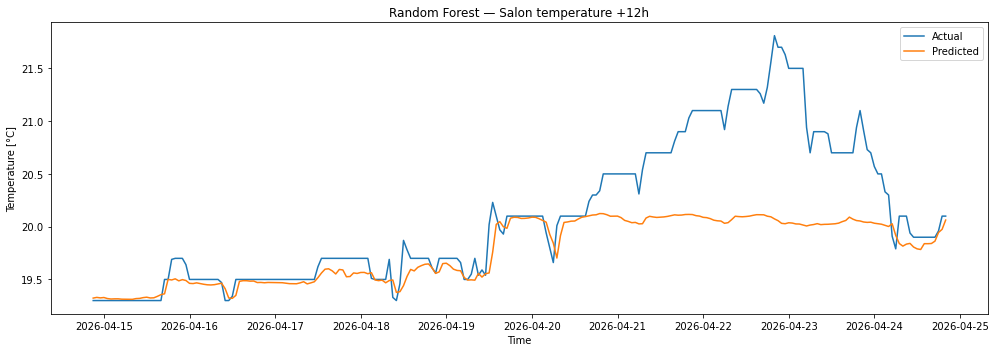

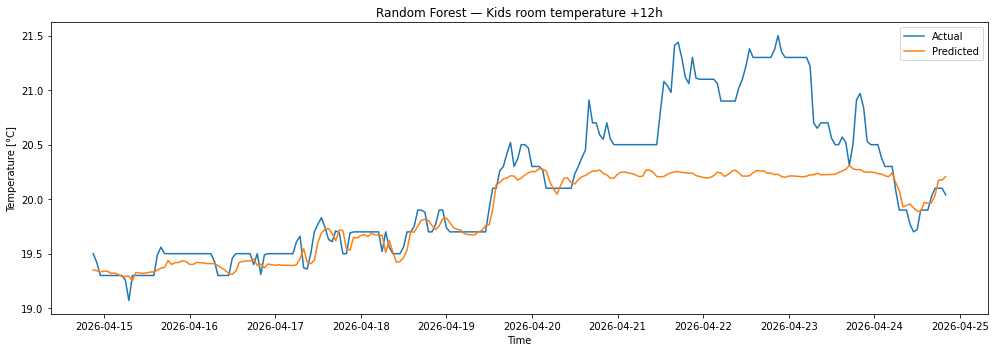

In [40]:
def plot_prediction(y_true, y_pred, target_col, title, n=240):
    plt.figure(figsize=(14, 5))
    plt.plot(y_true[target_col].iloc[:n].index, y_true[target_col].iloc[:n], label="Actual")
    plt.plot(y_pred[target_col].iloc[:n].index, y_pred[target_col].iloc[:n], label="Predicted")
    plt.title(title)
    plt.ylabel("Temperature [°C]")
    plt.xlabel("Time")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_prediction(y_test, rf_pred, target_cols[0], "Random Forest — Salon temperature +12h")
plot_prediction(y_test, rf_pred, target_cols[1], "Random Forest — Kids room temperature +12h")


## 10. Feature importance

In [41]:
# Built-in feature importance for Random Forest.

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(15))

temp_salon_c                      0.548013
temp_kids_c                       0.323761
temp_salon_c_roll_mean_2h         0.005540
temp_kids_c_roll_std_2h           0.005144
temp_salon_c_roll_std_2h          0.005104
temp_kids_c_roll_mean_24h         0.004796
temp_kids_c_lag_1h                0.004552
temp_salon_c_roll_mean_3h         0.003844
temp_kids_c_roll_mean_2h          0.003642
temp_salon_c_lag_1h               0.003338
solar_proxy_temp_delta_lag_48h    0.002878
temp_out_2_n_c_lag_48h            0.002490
solar_proxy_temp_delta_lag_24h    0.002270
temp_kids_c_roll_mean_12h         0.002218
hour_sin                          0.002205
dtype: float64


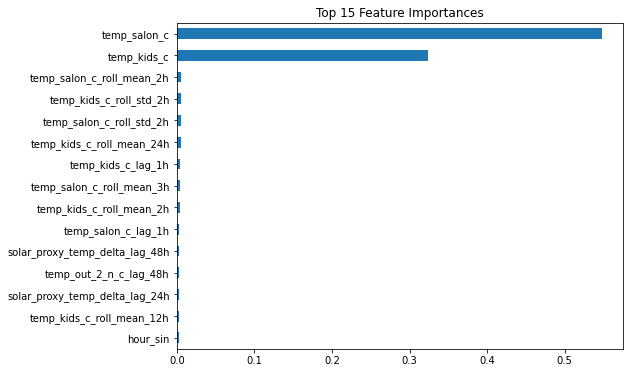

In [42]:
plt.figure(figsize=(8,6))
feature_importance.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.show()